# 1. 模型结构

- 使用yolo模型来举例。
    - transformers的设计模式

- 加载模型

In [2]:
from transformers import pipeline
pipe = pipeline("object-detection", model="F:/03Models/yolos-tiny")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


- 代码说明：
    - 如果加载出错，原因：transformers的版本。
        - 经典模型基本不会有问题：使用老技术。
        - 很多技术在新的版本中出现。flash_attn技术，对token的处理方式
            - 生成式模型与transfomers的版本更新关联性更大。
            - 生成式模型一般有一个文件：generation_config.json
                - 其中会配置transformers的版本。

- pipeline的工作原理
    - 模型
        - 必须有
    - 处理器（预pre，后post）：下面一个
        - _load_processor = False    # 多模态
        - _load_image_processor = True    # 机器视觉图像处理器
        - _load_feature_extractor = False    # 早期使用，强烈建议不推荐使用。未来可能不支持
        - _load_tokenizer = None          # 自然语言

In [12]:
# XXXPipeline
pipe.task
print(type(pipe.model))
print(type(pipe.model.config))
pipe.processor
print(type(pipe.image_processor))
pipe.feature_extractor   # 未来要取消（不是语音）
pipe.tokenizer

<class 'transformers.models.yolos.modeling_yolos.YolosForObjectDetection'>
<class 'transformers.models.yolos.configuration_yolos.YolosConfig'>
<class 'transformers.models.yolos.image_processing_yolos.YolosImageProcessor'>


-  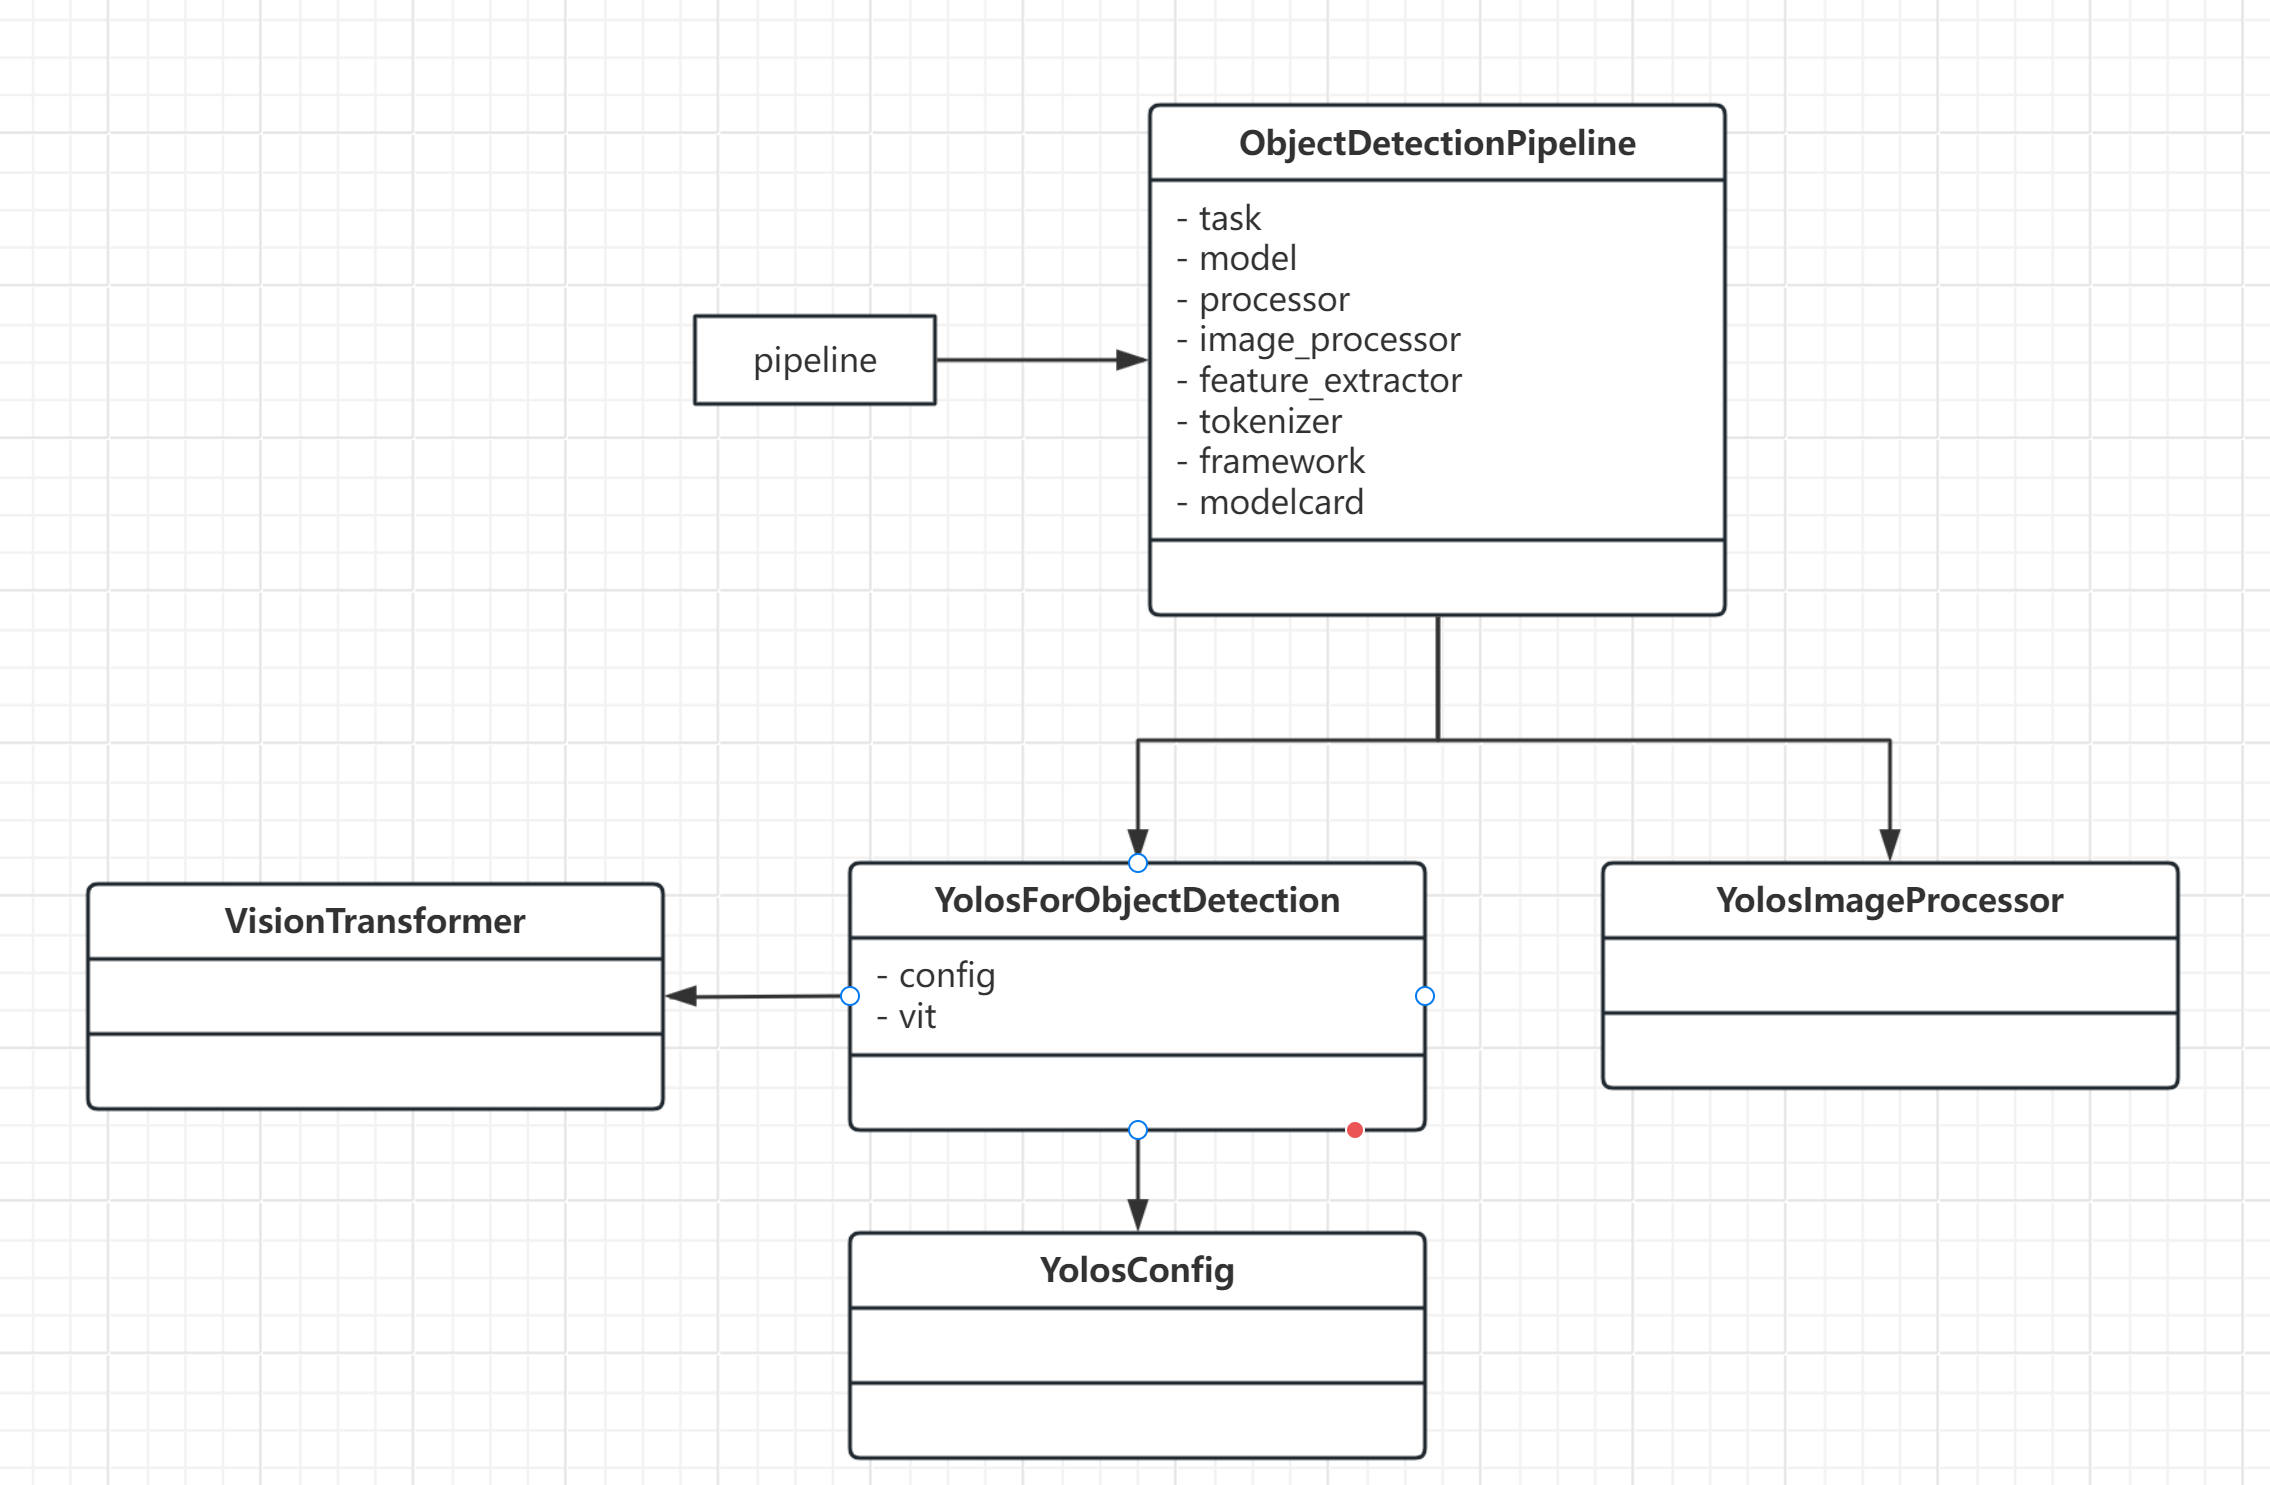

- pipeline的工作流

In [1]:
from transformers import pipeline
pipe = pipeline("object-detection", model="F:/03Models/yolos-tiny")
outputs = pipe("jiaotong.jpg")
outputs

W0325 15:14:19.215000 17824 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


-------


[{'score': 0.5431927442550659,
  'label': 'car',
  'box': {'xmin': 0, 'ymin': 1086, 'xmax': 300, 'ymax': 1256}},
 {'score': 0.5633091330528259,
  'label': 'car',
  'box': {'xmin': 974, 'ymin': 1031, 'xmax': 1195, 'ymax': 1115}},
 {'score': 0.9394692182540894,
  'label': 'car',
  'box': {'xmin': 1241, 'ymin': 1193, 'xmax': 4093, 'ymax': 3046}},
 {'score': 0.6565032601356506,
  'label': 'car',
  'box': {'xmin': 0, 'ymin': 1084, 'xmax': 122, 'ymax': 1242}},
 {'score': 0.9638065695762634,
  'label': 'person',
  'box': {'xmin': 1194, 'ymin': 982, 'xmax': 1817, 'ymax': 2305}},
 {'score': 0.7383183240890503,
  'label': 'car',
  'box': {'xmin': 32, 'ymin': 1149, 'xmax': 315, 'ymax': 1262}},
 {'score': 0.57694011926651,
  'label': 'car',
  'box': {'xmin': 241, 'ymin': 1135, 'xmax': 1480, 'ymax': 1770}},
 {'score': 0.7115415930747986,
  'label': 'car',
  'box': {'xmin': 177, 'ymin': 1198, 'xmax': 561, 'ymax': 1554}},
 {'score': 0.5100643634796143,
  'label': 'surfboard',
  'box': {'xmin': 1575, 

In [9]:
from transformers import pipeline
pipe = pipeline("object-detection", model="F:/03Models/yolos-tiny")

inputs = pipe.preprocess("jiaotong.jpg")
outputs = pipe.forward(model_inputs=inputs)
results = pipe.postprocess(outputs)
results

Device set to use cuda:0


[{'score': 0.5431927442550659,
  'label': 'car',
  'box': {'xmin': 0, 'ymin': 1086, 'xmax': 300, 'ymax': 1256}},
 {'score': 0.5633091330528259,
  'label': 'car',
  'box': {'xmin': 974, 'ymin': 1031, 'xmax': 1195, 'ymax': 1115}},
 {'score': 0.9394692182540894,
  'label': 'car',
  'box': {'xmin': 1241, 'ymin': 1193, 'xmax': 4093, 'ymax': 3046}},
 {'score': 0.6565032601356506,
  'label': 'car',
  'box': {'xmin': 0, 'ymin': 1084, 'xmax': 122, 'ymax': 1242}},
 {'score': 0.9638065695762634,
  'label': 'person',
  'box': {'xmin': 1194, 'ymin': 982, 'xmax': 1817, 'ymax': 2305}},
 {'score': 0.7383183240890503,
  'label': 'car',
  'box': {'xmin': 32, 'ymin': 1149, 'xmax': 315, 'ymax': 1262}},
 {'score': 0.57694011926651,
  'label': 'car',
  'box': {'xmin': 241, 'ymin': 1135, 'xmax': 1480, 'ymax': 1770}},
 {'score': 0.7115415930747986,
  'label': 'car',
  'box': {'xmin': 177, 'ymin': 1198, 'xmax': 561, 'ymax': 1554}},
 {'score': 0.5100643634796143,
  'label': 'surfboard',
  'box': {'xmin': 1575, 

- 直接使用模型与处理器
    - XXXPileline是最终用户的使用方式：简单

# 2. 处理器 - 推理的预处理与后处理

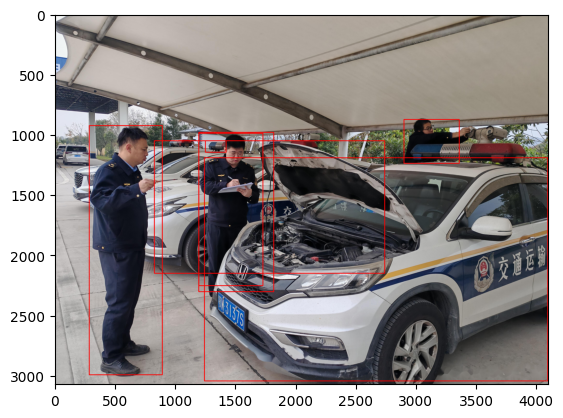

In [40]:
# 加载处理器
from transformers import YolosForObjectDetection, YolosImageProcessor
import torch

# 加载模型
model = YolosForObjectDetection.from_pretrained("F:/03Models/yolos-tiny") # model.safetensors + config.json
image_processor = YolosImageProcessor.from_pretrained("F:/03Models/yolos-tiny") # preprocessor_config.json
# 预处理
from transformers.image_utils import load_image
img = load_image("jiaotong.jpg") # PIL
target_size = torch.IntTensor([[img.height, img.width]])
inputs = image_processor(images=[img], return_tensors="pt")
#  模型接受的格式：两个参数pixel_values，target_size
inputs["target_size"] = target_size
# 模型推理
# torch.compile()
outputs = model(**inputs)   # 输入连个参数：pixel_values 与 target_size
# 后处理
results = image_processor.post_process_object_detection(outputs, threshold=0.8, target_sizes=target_size)  # 返回box是0-1的标准化的图像，需要还原
# 全部从gpu移到cpu，转换为numpy，类型转换
# print(results)
scores = results[0]["scores"].detach().cpu().numpy()
clsids = results[0]["labels"].detach().cpu().numpy()
import numpy as np
labels = np.array([model.config.id2label[ids] for ids in clsids])
boxes = results[0]["boxes"].detach().cpu().numpy().astype(int)
import cv2
jiao = cv2.imread("jiaotong.jpg", cv2.IMREAD_COLOR_RGB)
for s, l, b in zip(scores, labels, boxes):
    cv2.rectangle(jiao, pt1=(b[0], b[1]), pt2=(b[2], b[3]), color=(255, 0, 0), thickness=5)

import matplotlib.pyplot as plt
plt.imshow(jiao)
# =====================
# img
# import PIL.Image as Image
# import PIL.ImageOps as ImageOps
# # 加载
# img = Image.open("jiaotong.jpg")
# # 手机照片：旋转方向
# img = ImageOps.exif_transpose(img)   # 读取图像的元信息，实现自动旋转
# # 转换RGB
# img = img.convert("RGB")
# img

- 代码说明：
    - YolosForObjectDetection模型预测接受数据：
        - 两个参数：
            - pixel_values
            - target_size

```python
def forward(
        pixel_values: torch.FloatTensor,         # 输入的图像
        labels: Optional[list[dict]] = None,     # 标签（推理没有标签）
        **kwargs: Unpack[TransformersKwargs],    # target_size = 推理以后，把数据还原成原图像大小
    ) -> YolosObjectDetectionOutput:
```

- forward返回两种格式：
    - 推理：不输入labels
        - logits
        - pred_boxes 
    - 训练：输入label
        - 返回其他